# **Perceptrons PC.1)** Mostre que uma rede neural pode ser re-treinada (adaptada) para se ajustar a um ambiente variante no tempo. 

## Definição da MLP:

In [25]:
# Basic models used to build a multilayer perceptron that
# uses a backpropagation algorithm to learn from data.
#
# Author: Prof. Fabrício Galende Marques de Carvalho
#
import numpy as np

class Neuron:
    """ 
    Basic neuron model used to build a single
    processing unit.
    """
    def __init__(self, act_func, d_act_func, pre_act=0, post_act=0):
        self.activation_function = act_func
        self.activation_function_derivative = d_act_func
        self.pre_activation = pre_act
        self.post_activation = post_act

    def process(self,v):
        self.pre_activation = v
        self.post_activation = self.activation_function(v)
        return self.post_activation

    def process_d(self):
        return self.activation_function_derivative(self.pre_activation)


class Layer:
    """
    Model for a single processing Layer.
    Once a layer is created, an additional input is always created
    to include bias.
    """
    def __init__( self, dimension, neuron_model, act_func, d_act_func ):
        """
        dimension: number of neurons in the layer
        No initial condition is passed to neurons. To change it, each
        neuron must be accessed through self.neurons array.
        """
        self.dimension = dimension
        self.neuron_model = neuron_model
        self.neurons = np.empty(dimension, dtype=object)
        self.pre_activation = np.zeros((dimension,1))
        self.post_activation = np.zeros((dimension,1))
        self.local_derivatives = np.zeros((dimension,1))
        for neuron_index in range(dimension):
            self.neurons[neuron_index] = neuron_model(act_func, d_act_func)   

    def process(self, v, learn=False):
        """
        v is the vector (dimension x1), which corresponds
        to the local field for each neuron
        """
        self.pre_activation = np.array(v).reshape(-1,1) ## reshape(-1,1) -> any number of lines and only one column
        output = []
        deriv = []
        for i,neuron in enumerate(self.neurons):
            output.append(neuron.process(v[i]))
            if learn:
                deriv.append(neuron.process_d())
        self.post_activation = np.array(output).reshape(-1,1)
        if learn:
            self.local_derivatives = np.array(deriv).reshape(-1,1)
        return np.array(output).reshape(-1,1)

    def process_d(self):
        output = []
        for neuron in self.neurons:
            output.append(neuron.process_d()[0])
        self.local_derivatives = np.array(output).reshape(-1,1)
        return self.local_derivatives

class FFNeuralNetwork:
    """
      A class that models a feedforward neural network
    """
    def __init__(self, topology, layers, W0 = None, zero_init = False, rand_seed = 0):
        """
         topology: array that contains the number of neurons
         per layer, including input layer (i.e., a network
         with topology [3,2,1] contains three inputs, 2 
         neurons in the hidden layer and one output layer.
        """
        self.topology = topology        # defines a dense feedforward NN
        self.n_layers = len(topology)-1 # number of processing layers
        self.layers = layers
        self.weights = W0
        if self.weights is None: # no initialization was provided
            self.weights = []
            if not zero_init: #random initialization is performed
                np.random.seed(rand_seed)
                for i in range(len(topology)-1):
                    #negative and positive initial weights: 
                    self.weights.append(np.random.uniform(low=-1.0, high=1.0, size=(self.topology[i+1], self.topology[i] + 1))) 
                    # only positive initial weights:
                    # self.weights.append(np.random.rand(self.topology[i+1],self.topology[i]+1)) ## bias is taken into account here
            else:
                for i in range(len(topology)-1):
                    self.weights.append(np.zeros((self.topology[i+1],self.topology[i]+1))) ## bias is taken into account here

    def process(self, x, learn=False):
        """
        Performs the forward propagation and gets neural network output from
        vector input x
        """
        for i, layer in enumerate(self.layers):
            if i == 0:
                x_in = np.vstack( (x,[[1]] )) # here we stack the bias input for the first layer 
            else:
                x_in = np.vstack( [self.layers[i-1].post_activation, [[1]]]) 
            v = self.weights[i] @ x_in
            layer.process(v, learn)
        return self.layers[self.n_layers-1].post_activation

    def backprop(self, x, y_d, eta):
        """
        Here we implement the backpropagation algorithm.
        It is assumed that x and y_d are both column vectors and 
        it is also assumed that the layers were appropriately
        initialized.

        This algorithm is implemented for a single example learning 
        and it can be easily wrapped in a version that is applicable
        to some training set.

        eta: learning rate
        """

        # First we propagate through the network
        output = self.process(x, learn=True)
        # Then we compute the output error vector
        error_vector = y_d - output

        # Now we compute the gradients for the output and hidden layers, in
        # reverse order
        grad_indices = list(range(self.n_layers))
        grad_indices.reverse()
        local_grads = []
        for i in range(self.n_layers):
            local_grads.append(np.zeros((self.topology[i+1],1)))
        for l_idx in grad_indices:
            if l_idx == (self.n_layers - 1) : #output layer
                 #local gradient for the output layer
                 delta_k = error_vector * self.layers[self.n_layers-1].local_derivatives  #element-wise operation
                 local_grads[l_idx] = delta_k
            else:                 
                # delta_k_1 = phi'(v_k_1) *  (W_k^T. delta_k ) 
                delta_k_1 =  self.layers[l_idx].local_derivatives * (self.weights[(l_idx + 1)][:, :-1].T @ local_grads[(l_idx+1)] )
                local_grads[l_idx] = delta_k_1
        # now we can compute the appropriate weight corrections:
        for i in range(self.n_layers):
            if i == 0: #input layer
                self.weights[i] = self.weights[i] + eta * local_grads[i] @ np.vstack((x,[[1]])).T
            else:
                self.weights[i] = self.weights[i] + eta * local_grads[i] @ np.vstack( (self.layers[i-1].post_activation, [[1]])).T
        #Return the error just to measure the training process effectiveness:
        return error_vector       

# (a) Treine uma RNA para uma determinada tarefa de classificação, utilizando um determinado conjunto de dados.

## Leitura dos Dados:

In [ ]:
!pip install pandas seaborn

In [78]:
import pandas as pd
data = pd.read_csv('./sample_data/samples.csv')
data = data[['longitude', 'latitude', 'start_date', 'end_date', 'label', 'time_series']]
data = data[data['label'].isin(['Pastagem', 'Vegetação-Secundária'])]
print('Labels = ', set(data['label']))
data

Labels =  {'Vegetação-Secundária', 'Pastagem'}


,longitude,latitude,start_date,end_date,label,time_series
0,-44.783750,-18.239786,2021-12-31,2022-08-31,Vegetação-Secundária,"{""Index"":[""2022-01-01"",""2022-01-17"",""2022-02-0..."
1,-44.763759,-18.514987,2021-12-31,2022-08-31,Pastagem,"{""Index"":[""2022-01-01"",""2022-01-17"",""2022-02-0..."
2,-46.384140,-18.197988,2021-12-31,2022-08-31,Vegetação-Secundária,"{""Index"":[""2022-01-01"",""2022-01-17"",""2022-02-0..."
3,-45.320681,-18.258134,2021-12-31,2022-08-31,Pastagem,"{""Index"":[""2022-01-01"",""2022-01-17"",""2022-02-0..."
4,-45.942721,-18.414147,2021-12-31,2022-08-31,Vegetação-Secundária,"{""Index"":[""2022-01-01"",""2022-01-17"",""2022-02-0..."
...,...,...,...,...,...,...
829,-46.368034,-18.250444,2021-12-31,2022-08-31,Vegetação-Secundária,"{""Index"":[""2022-01-01"",""2022-01-17"",""2022-02-0..."
830,-46.412601,-18.154497,2021-12-31,2022-08-31,Vegetação-Secundária,"{""Index"":[""2022-01-01"",""2022-01-17"",""2022-02-0..."
831,-46.513667,-18.117955,2021-12-31,2022-08-31,Vegetação-Secundária,"{""Index"":[""2022-01-01"",""2022-01-17"",""2022-02-0..."
832,-44.657064,-19.677350,2021-12-31,2022-08-31,Pastagem,"{""Index"":[""2022-01-01"",""2022-01-17"",""2022-02-0..."


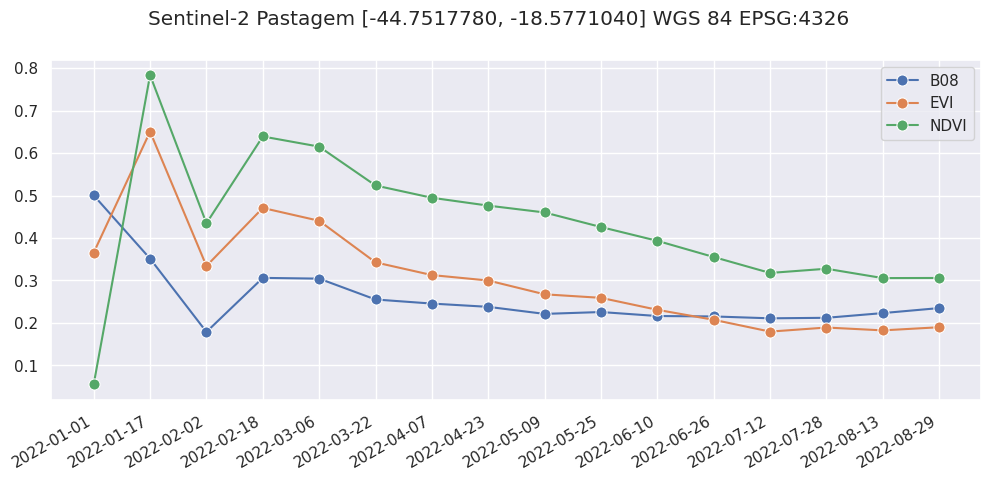

In [80]:
import json
import matplotlib.pyplot as plt
import random
import seaborn

def plot_ts(data_df, selected_line):
    ts = pd.DataFrame(json.loads(data_df['time_series'][selected_line]))
    fig = plt.figure(figsize = (12, 5))
    fig.suptitle(
        ("Sentinel-2 {label} [{lng:,.7f}, {lat:,.7f}] WGS 84 EPSG:4326 ").format(
            label=data_df['label'][selected_line],
            lng=data_df['longitude'][selected_line],
            lat=data_df['latitude'][selected_line]
        )
    )
    seaborn.set_theme(style="darkgrid")
    bands = [ band for band in list(ts.keys()) if band != 'Index']
    for band in bands:
        seaborn.lineplot(
            data = ts,
            x = "Index", y = band, label = band,
            markersize = 8, marker = 'o',
            linestyle = '-', picker = 10
        )
    fig.autofmt_xdate()
    plt.xlabel(None)
    plt.ylabel(None)
    plt.legend()
    plt.show()

plot_ts(data, random.randint(0, (len(data) - 1)))

## Preparação dos Dados:

Descrição geral (Overview) do Dataset:

- Conjuntos de séries temporais (769 registros);

- 16 observações no tempo (16 datas ou _timestamps_);

- Para 3 bandas: B08 (Near-Infrared - NIR), EVI (Índice de Vegetação Melhorado) e NDVI (Índice de Vegetação da Diferença Normalizada);

- O conjunto de dados é composto por 2 classes: 'Vegetação-Secundária' e 'Pastagem'.

Vegetação => NDVI alto e estável

Pastagem => NDVI mais variável

**Note**: "O NDVI (Índice de Vegetação da Diferença Normalizada) mede o vigor da vegetação através da clorofila, enquanto o EVI (Índice de Vegetação Melhorado) é uma versão aprimorada que corrige influências atmosféricas e do solo."

## Primeiro é necessário transformar as séries temporais em um vetor numérico ou _flatten_:

- Tranformar as séries temporais para "[B08_1...B08_16, EVI_1...EVI_16, NDVI_1...NDVI_16]";

- Transformar as labels 'Vegetação-Secundária' e 'Pastagem' em  0 e 1.

In [81]:
import numpy as np

### Método para o flatten
def extract_features(ts_string):
    ts = json.loads(ts_string.replace('""', '"'))
    
    b08 = np.array(ts["B08"])
    evi = np.array(ts["EVI"])
    ndvi = np.array(ts["NDVI"])
    
    return np.concatenate([b08, evi, ndvi])

random_sample = random.randint(0, (len(data) - 1))

original = data['time_series'][random_sample]
flatten = extract_features(original)

### Método para codificar as labels
def encode_label(label):
    if label == "Vegetação-Secundária":
        return np.array([[0]])
    else:  # Pastagem
        return np.array([[1]])

label = data['label'][random_sample]
label_code = encode_label(label)

print(f"Original => ({label}): ", original, "\n")
print(f"Flatten => ({label_code}): ", flatten)
print()

Original => (Pastagem):  {"Index":["2022-01-01","2022-01-17","2022-02-02","2022-02-18","2022-03-06","2022-03-22","2022-04-07","2022-04-23","2022-05-09","2022-05-25","2022-06-10","2022-06-26","2022-07-12","2022-07-28","2022-08-13","2022-08-29"],"B08":[0.3615,0.4226,0.5338,0.3857,0.3702,0.3473,0.271,0.2239,0.2145,0.2105,0.2031,0.2014,0.2017,0.206,0.2084,0.2264],"EVI":[0.6002,0.6683,0.8391,0.6061,0.5647,0.5687,0.3839,0.2989,0.2727,0.207,0.1641,0.1602,0.1495,0.147,0.1474,0.1423],"NDVI":[0.691,0.7671,0.7564,0.7245,0.718,0.7319,0.5993,0.5069,0.4765,0.3692,0.3078,0.2969,0.2736,0.2646,0.2651,0.2434]} 

Flatten => ([[1]]):  [0.3615 0.4226 0.5338 0.3857 0.3702 0.3473 0.271  0.2239 0.2145 0.2105
 0.2031 0.2014 0.2017 0.206  0.2084 0.2264 0.6002 0.6683 0.8391 0.6061
 0.5647 0.5687 0.3839 0.2989 0.2727 0.207  0.1641 0.1602 0.1495 0.147
 0.1474 0.1423 0.691  0.7671 0.7564 0.7245 0.718  0.7319 0.5993 0.5069
 0.4765 0.3692 0.3078 0.2969 0.2736 0.2646 0.2651 0.2434]



## Aplicando para todo o dataset:

In [82]:
X = []
Y = []

for _, row in data.iterrows():
    X.append(extract_features(row["time_series"]))
    Y.append(encode_label(row["label"]))

X = np.array(X)
Y = np.array(Y)

## Agora é necessário normalizar os dados de entrada X para um treinamento mais estável:

Pois as observações não estão na mesma escala estatística, mesmo que pareçam “normalizados”.

- NDVI: está em "[-1, 1]"
- EVI: pode sair desse intervalo;
- NIR: reflectância (0 a ~1).

**Note**: Normalizar com média e desvio padrão significa subtrair a média e dividir pelo desvio padrão de cada variável, fazendo com que todas passem a ter média 0 e desvio padrão 1, evitando que diferenças de escala influenciem o aprendizado da rede.

In [83]:
X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)
X

array([[ 2.20767467,  0.08052717, -1.18791509, ...,  1.50703961,
         1.39357002,  1.4191791 ],
       [ 2.00773155,  0.32777163,  1.13502699, ..., -1.61391649,
        -1.50744382, -1.43823618],
       [-0.52034924,  4.18258739, -0.73075221, ...,  1.09231314,
         1.08021295,  1.12851995],
       ...,
       [-1.01220931, -1.60293285, -1.32658484, ...,  1.36808265,
         1.19710662,  1.15850542],
       [ 3.50410585,  0.65413431,  0.72572755, ..., -0.41991597,
        -0.39510824, -0.5246789 ],
       [ 2.99385101,  0.96950835,  1.28577444, ..., -0.72013162,
        -0.67893428, -0.68939907]])

## Definição da arquitetura MLP

Essa rede possui 48 entradas, 10 neurônios ocultos e uma 1 saída.

Função de ativação sigmoid das camadas ocultas.

Na camada de saída => sigmoid.

Inicialização dos pesos de forma aleatória.

Entrada >> Soma ponderada >> Ativação >> Próxima camada >> Saída.

Aprender padrões temporais da vegetação.

### Definição da função sigmoid:

![image.png](./img/sigmoid_formula.png)

![image.png](./img/sigmoid.png)

In [37]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def d_sigmoid(x):
    s = sigmoid(x)
    return s * (1 - s)

### Definição da função tangente hiperbólica:

![image.png](./img/tanh_formula.png)

![image.png](./img/tanh.png)

In [38]:
def tanh(x):
    return np.tanh(x)

def d_tanh(x):
    return 1 - np.tanh(x)**2

### OBS.: Por que usar tangente hiperbólica (tanh) nas camadas ocultas e na camada de saída a sigmoid:

Melhorar o aprendizado por três motivos principais:

- Deixar a saída centrada em zero a 'tanh' varia de -1 a 1, já a 'sigmoid' varia de 0 a 1, dessa forma mantém a média das ativações próxima de zero

- Deixar os gradientes mais equilibrados, melhorar a propagação dos gradientes deixando o treinamento mais rápido. A 'tanh' mantém aprendizado ativo por mais tempo, consegue equilibrar decisões mais facilmente, já a sigmoid “achata” muito rápido;

- Usar a 'tanh' funciona melhor, pois os dados têm variações (altos e baixos) padrões temporais ficam mais fáceis de representar com valores positivos e negativos.

In [84]:
# Entrada (48 features)
#    x1
#    x2
#    x3
#    ...
#    x48
#     │
#     ▼
   
# +-------------------+
# |  Camada Oculta    |   (10 neurônios)
# |   o  o  o  o  o   |
# |   o  o  o  o  o   |
# +-------------------+
#     │
#     ▼
# +-------------------+
# |  Saída (1)        |
# |        o          |
# +-------------------+
#     │
#     ▼
# Classe (0 ou 1)

# v_j = w1*x1 + w2*x2 + ... + w48*x48 + bias

# y_j = sigmoid(v_j)

input_size = 48 ## 16 timestamps x 3 bandas = 48 entradas

seed = 567

topology = [input_size, 10, 1]

layers = [
    Layer(10, Neuron, tanh, d_tanh),
    Layer(1, Neuron, sigmoid, d_sigmoid)
]

# nn = FFNeuralNetwork(topology, layers, rand_seed = seed)
nn = FFNeuralNetwork(topology, layers)

### Finalmente... O treinamento:

Usando 500 épocas e um taxa de aprendizado de 0.05.

Explicar o backpropagation.

Epoch 0, Erro médio: 0.07302472435978993
Epoch 100, Erro médio: -0.0019720197455602934
Epoch 200, Erro médio: 0.005951047361035519
Epoch 300, Erro médio: 0.0006528489700532144
Epoch 400, Erro médio: 0.0021685200431019553


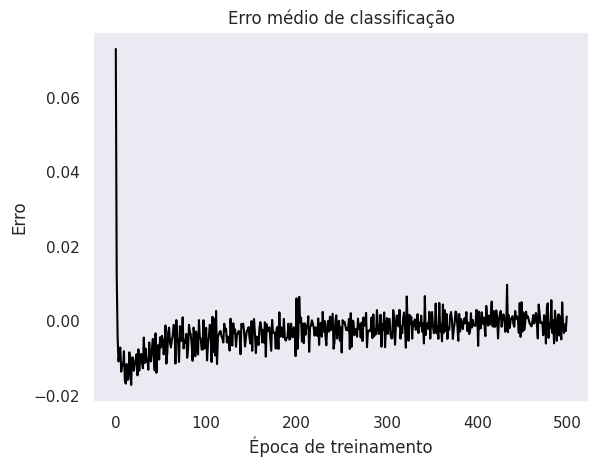

In [104]:
from random import shuffle

learning_rate =  0.05
n_epochs = 500

e_epoch = []             # erro médio por época
e_instantaneous = []     # erro por amostra
w_0_epoch = []           # acompanhar peso (opcional)

indices = list(range(len(X)))

for epoch in range(n_epochs):
    e_point = []
    shuffle(indices)
    
    for k in indices:
        x = X[k].reshape(-1,1)
        y = Y[k]
        
        # forward + backprop
        error = nn.backprop(x, y, learning_rate)
        
        # erro escalar (MSE simplificado)
        err_val = error[0][0]
        
        e_point.append(err_val)
        e_instantaneous.append(err_val)
    
    # erro médio da época
    e_epoch.append(np.mean(e_point))
    
    # armazenar um peso para monitoramento (ex: primeiro peso)
    w_0_epoch.append(nn.weights[0][0][0])
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Erro médio: {e_epoch[-1]}")

plt.plot(e_epoch, color="black")
plt.title("Erro médio de classificação")
plt.xlabel("Época de treinamento")
plt.ylabel("Erro")
plt.grid()
plt.show()

# (b) Altere o conjunto de dados utilizados no primeiro treinamento e mostre que o desempenho da rede é comprometido ou degradado.

Entender o processo de generalização (_underfitting_) e _overffiting_ (superajuste) do modelo.

O processo de generalização ocorre quando a rede não consegue estabelecer uma relação entre os dados de entrada, entre a label e suas características.

Vamos realizar dois esperimentos, um menos realista e outro mais realista.

O primeiro vamos embaralhar os dados.

No segundo iremos aplicar ruído nos dados.

## Primeiro experimento:

Enbaralhar os dados do início, para confundir o modelo (conjunto de dados bem ruins (bad_data)).

In [105]:
import copy

Y_bad = copy.deepcopy(Y)

# embaralha as labels Y para o X
indices = list(range(len(Y_bad)))
shuffle(indices)

Y_bad = Y_bad[indices]

### Treinamento com o nosso "bad_data":

In [108]:
learning_rate = 0.05
n_epochs = 500

e_epoch_bad = []

indices = list(range(len(X)))

for epoch in range(n_epochs):
    e_point = []
    shuffle(indices)
    
    for k in indices:
        x = X[k].reshape(-1,1)
        y = Y_bad[k]   # labels errados
        
        error = nn.backprop(x, y, learning_rate)
        err_val = error[0][0]
        e_point.append(err_val)
    
    e_epoch_bad.append(np.mean(e_point))
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Erro médio: {e_epoch_bad[-1]}")

Epoch 0, Erro médio: -0.006326522907608806
Epoch 100, Erro médio: -0.0010310365144510678
Epoch 200, Erro médio: -0.0018707248414199947
Epoch 300, Erro médio: -0.002934289431128636
Epoch 400, Erro médio: -0.007608920994773259


### Comparação do treinamento com dados bons (reais) e com dados ruins:

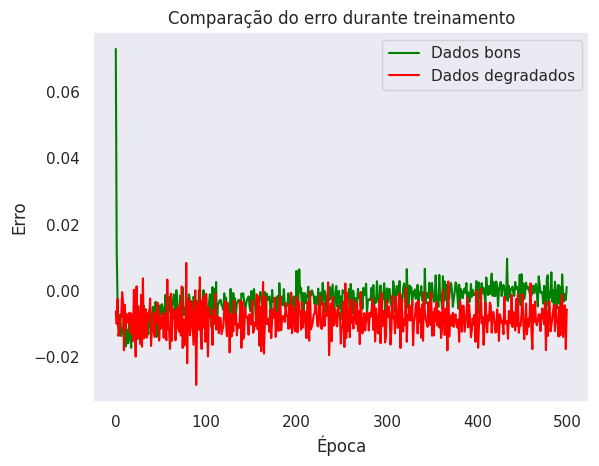

In [109]:
plt.plot(e_epoch, label="Dados bons", color="green")
plt.plot(e_epoch_bad, label="Dados degradados", color="red")

plt.title("Comparação do erro durante treinamento")
plt.xlabel("Época")
plt.ylabel("Erro")
plt.legend()
plt.grid()
plt.show()

Com os dados reais o erro vai diminuindo ao longo das épocas, porém com os dados ruins (bad_data) embaralhados o erro permanece instável e aleatório, quase em um padrão de linha reta.

Os dados ruins não apresentam uma relação clara entre entrada e saída.

Logo MLP não consegue aprender padrão, erro não converge.

## Segundo experimento:

Adicionar ruído aos dados de entrada X de forma aleatória aos dados bons (reais).

In [110]:
noise = np.random.normal(0, 0.5, X.shape)
X_noisy = X + noise

### Treinamento com o noisy_data:

In [111]:
learning_rate = 0.05
n_epochs = 500

e_epoch_noisy = []

indices = list(range(len(X)))

for epoch in range(n_epochs):
    e_point = []
    shuffle(indices)
    
    for k in indices:
        x = X_noisy[k].reshape(-1,1) # dados com ruído
        y = Y[k]
        
        error = nn.backprop(x, y, learning_rate)
        err_val = error[0][0]
        e_point.append(err_val)
    
    e_epoch_noisy.append(np.mean(e_point))
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Erro médio: {e_epoch_bad[-1]}")

Epoch 0, Erro médio: -0.0056911853812874605
Epoch 100, Erro médio: -0.0056911853812874605
Epoch 200, Erro médio: -0.0056911853812874605
Epoch 300, Erro médio: -0.0056911853812874605
Epoch 400, Erro médio: -0.0056911853812874605


### Comparação do treinamento com dados bons (reais) e com dados ruidosos:

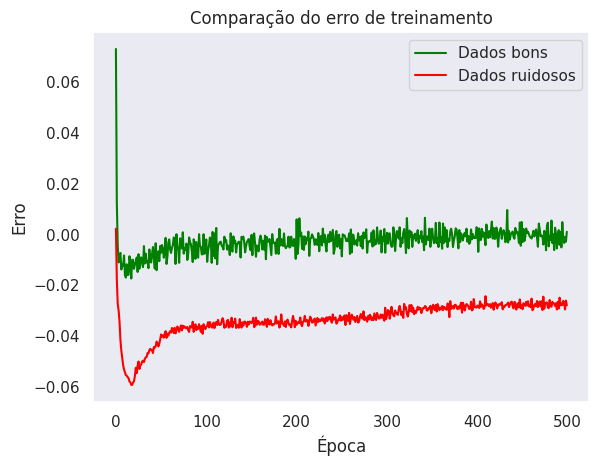

In [112]:
plt.plot(e_epoch, label="Dados bons", color="green")
plt.plot(e_epoch_noisy, label="Dados ruidosos", color="red")

plt.title("Comparação do erro de treinamento")
plt.xlabel("Época")
plt.ylabel("Erro")
plt.legend()
plt.grid()
plt.show()

Com os dados ruidosos o modelo aprende mais devagar, o erro converge devagar no decorrer das épocas.

# (c) Proceda com um novo treinamento sobre a mesma rede e verifique se o desempenho da rede melhora e agora é capaz de ter bom desempenho tanto no conjunto de dados original como no novo conjunto de dados.

Objetivo testar a generalização da rede.

Vamos realizar um novo experiento com uma nova sessão de treinamento usando os dados originais somados aos dados ruidosos.

In [113]:
# adicionar um ruído leve
noise = np.random.normal(0, 0.2, X.shape)
X_noisy = X + noise

# combinar os datasets
X_combined = np.vstack((X, X_noisy))
Y_combined = np.vstack((Y, Y))

## Treinamento com os dados combinados:

In [114]:
learning_rate = 0.05
n_epochs = 500

e_epoch_combined = []

indices = list(range(len(X_combined)))

for epoch in range(n_epochs):
    e_point = []
    np.random.shuffle(indices)
    
    for k in indices:
        x = X_combined[k].reshape(-1,1)
        y = Y_combined[k]
        
        error = nn.backprop(x, y, learning_rate)
        err_val = error[0][0]
        e_point.append(err_val)
    
    e_epoch_combined.append(np.mean(e_point))
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Erro médio: {e_epoch_bad[-1]}")

Epoch 0, Erro médio: -0.0056911853812874605
Epoch 100, Erro médio: -0.0056911853812874605
Epoch 200, Erro médio: -0.0056911853812874605
Epoch 300, Erro médio: -0.0056911853812874605
Epoch 400, Erro médio: -0.0056911853812874605


### Comparação do treinamento com dados bons (reais) e com dados ruidosos:

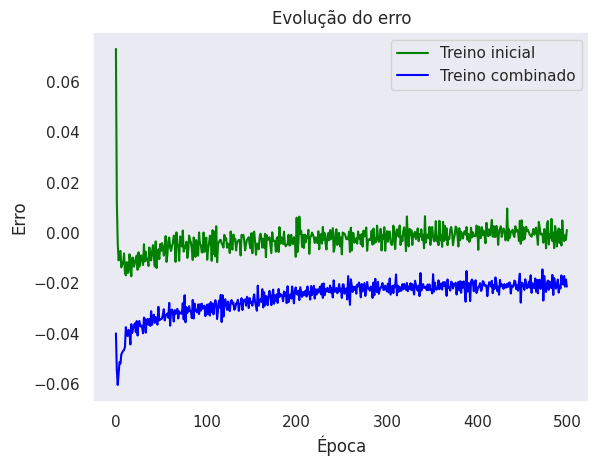

In [115]:
plt.plot(e_epoch, label="Treino inicial", color="green")
plt.plot(e_epoch_combined, label="Treino combinado", color="blue")

plt.title("Evolução do erro")
plt.xlabel("Época")
plt.ylabel("Erro")
plt.legend()
plt.grid()
plt.show()

No treinamento inicial tivemos um desempenho moderadamente bom, com os dados ruins ou ruidosos a rede se perdeu pois não tinha uma relação clara entre os dados de entrada, então o erro não converge.

No último experimento, o erro da rede converge mais devagar, identificando que essa rede aprendeu o padrão das séries, as características mais essenciaias, o robusto, não os detalhes específicos evitando o _overfitting_.

Treinar com dados representativos melhora a robustez da rede, aprende mais características.

**Note:** Minha tese de doutorado envolve a questão da análise de qualidade e seleção de amostras para melhorar a representatividade dos dados de treinamento e consequentemente melhorar os resultados da classificação.